In [19]:
import torch.nn as nn
import torch.nn.functional as F
import torch
import torchvision.datasets.cifar as cf
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import PIL.Image as Image
from torch.utils.data import DataLoader,Dataset
from tqdm import tqdm
from torch.utils.data import random_split
from torch.optim.lr_scheduler import StepLR
import numpy as np
import wandb
import pandas as pd
import os
import torchvision.models as models
os.mkdir("./trained_models")


In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
N_CHANNELS = 3



In [21]:
class DatasetChecko(Dataset):
    def __init__(self,data_path,gt_path):
        super().__init__()
        self.data_path = data_path
        self.gt = gt_path
        self.filepaths = []
        self.labels = []

        data_dir = os.listdir(self.data_path)

        gt = pd.read_csv(self.gt)
        for idx, fname in enumerate(data_dir):
            if fname.lower().endswith(('.png','.jpg')):
                gtrow = gt.loc[gt["filename"] == fname]
                if len(gtrow) > 0:
                    self.filepaths.append(os.path.join(self.data_path,fname))
                    gt_string = gtrow['corners'].values[0]
                    gt_coords = [float(x) for x in gt_string.split()]
                    gt_coords.append(gtrow['check_corners'].values[0])
                    self.labels.append(gt_coords)

    def __len__(self,):
        return len(self.filepaths)

    def __getitem__(self,idx):
        image_name = self.filepaths[idx]
        label = self.labels[idx]
        image = Image.open(image_name)
        orig_w, orig_h = image.size
        image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT))
        image_transform = transform(image)
        label = self.labels[idx].copy() #do nto alter saved list
        for i in range(0,8,2):
            label[i] = label[i]/orig_w
            label[i+1] = label[i+1]/orig_h
        label = torch.tensor(label, dtype=torch.float32)

        return image_transform,label

In [22]:
dataset_train = DatasetChecko("/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images","/content/drive/MyDrive/tag_boundary_detection_training_data/train_corners.csv")
dataset_val = DatasetChecko("/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images","/content/drive/MyDrive/tag_boundary_detection_training_data/val_corners.csv")

In [23]:
print(len(dataset_train),len(dataset_val))

4745 1614


In [24]:
def BatchLoader(dataset,batch_size,train_flag):
    dataloader = DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True if train_flag else False, drop_last=True)
    return dataloader

In [25]:
class DetectCorner(nn.Module):
    def __init__(self,):
        super().__init__()
        self.base_model = models.resnet18(pretrained=True)
        for param in self.base_model.parameters():
            param.requires_grad = False
        for param in self.base_model.layer4.parameters():
            param.requires_grad = True

        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Linear(num_features, 9) #(8 coords and 1 conf)

    def forward(self,x):
        out = self.base_model(x)
        coords = out[:,:8]
        conf_logits = out[:,8:]

        return coords, conf_logits

In [26]:
class DetectCornerEff(nn.Module):
    def __init__(self,):
        super().__init__()
        self.base_model = models.efficientnet_b0(weights="DEFAULT")
        # for param in self.base_model.parameters():
        #     param.requires_grad = False
        # for param in self.base_model.layer4.parameters():
        #     param.requires_grad = True

        num_features = self.base_model.classifier[1].in_features
        self.base_model.classifier[1] = nn.Linear(num_features, 9) #(8 coords and 1 conf)

    def forward(self,x):
        out = self.base_model(x)
        coords = out[:,:8]
        conf_logits = out[:,8:]

        return coords, conf_logits



In [27]:
class DetectCornerConvX(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = models.convnext_tiny(weights="DEFAULT")

        for param in self.base_model.parameters():
            param.requires_grad = False

        num_features = self.base_model.classifier[2].in_features
        self.base_model.classifier[2] = nn.Linear(num_features, 9)

    def forward(self, x):
        out = self.base_model(x)
        coords = out[:, :8]
        conf_logits = out[:, 8:]
        return coords, conf_logits

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS =4
EPS = float("inf")
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 0.0001
MODEL_DIR = "./trained_models"
w1 = 1
w2 = 1
MODEL_SELECT = DetectCornerConvX() #DetectCornerEff #DetectCorner

model = DetectCornerConvX().to(device=device)
optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
# scheduler = StepLR(optimizer,step_size=int(np.floor(EPOCHS/10)),gamma=0.1)

train_loader = BatchLoader(dataset=dataset_train,batch_size=BATCH_SIZE,train_flag=True)
valid_loader = BatchLoader(dataset=dataset_val,batch_size=BATCH_SIZE,train_flag=False)

In [29]:
print(device)

cuda


In [30]:
for name, param in model.base_model.named_parameters():
    print(f"{name:40s} | requires_grad={param.requires_grad}")


features.0.0.weight                      | requires_grad=False
features.0.0.bias                        | requires_grad=False
features.0.1.weight                      | requires_grad=False
features.0.1.bias                        | requires_grad=False
features.1.0.layer_scale                 | requires_grad=False
features.1.0.block.0.weight              | requires_grad=False
features.1.0.block.0.bias                | requires_grad=False
features.1.0.block.2.weight              | requires_grad=False
features.1.0.block.2.bias                | requires_grad=False
features.1.0.block.3.weight              | requires_grad=False
features.1.0.block.3.bias                | requires_grad=False
features.1.0.block.5.weight              | requires_grad=False
features.1.0.block.5.bias                | requires_grad=False
features.1.1.layer_scale                 | requires_grad=False
features.1.1.block.0.weight              | requires_grad=False
features.1.1.block.0.bias                | requires_gra

In [31]:
bce_loss = nn.BCEWithLogitsLoss()
def loss_fn(pred_coords, pred_logits,true_labels):
    true_coords = true_labels[:,:8]
    true_logits = true_labels[:,8:]

    MSE = torch.mean((pred_coords - true_coords) ** 2)
    BCE = bce_loss(pred_logits, true_logits)

    total_loss = w1*MSE + w2*BCE
    return total_loss



In [32]:
def train_loop(train_loader,optimizer,device):
    model.train()
    total_train_loss = 0
    for batch_idx, (batch_data,batch_labels) in enumerate(tqdm(train_loader)):
        batch_data = batch_data.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad()
        pred_coords, pred_logits = model(batch_data)
        loss = loss_fn(pred_coords, pred_logits,batch_labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss/len(train_loader)
    return avg_train_loss

def val_loop(val_loader,device):
    model.eval()
    total_val_loss = 0
    for batch_idx, (batch_data,batch_labels) in enumerate(tqdm(val_loader)):
        batch_data = batch_data.to(device)
        batch_labels = batch_labels.to(device)
        with torch.no_grad():
            pred_coords, pred_logits = model(batch_data)

            loss = loss_fn(pred_coords, pred_logits,batch_labels)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss/len(val_loader)
    return avg_val_loss

train_loss_list = []
valid_loss_list = []

try:

  for epoch in range(EPOCHS):
      train_avg_loss = train_loop(train_loader,optimizer,device)
      val_avg_loss = val_loop(valid_loader,device)
      # scheduler.step()
      print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_avg_loss:.4f} | Val Loss: {val_avg_loss:.4f}")
      checkpoint = {'epoch' : epoch, 'model_state_dict' : model.state_dict(), 'optimizer_state_dict' : optimizer.state_dict(), 'loss' : train_avg_loss, }
      if val_avg_loss < EPS:
          EPS = val_avg_loss
          torch.save(checkpoint, os.path.join(MODEL_DIR,"Resnet18.pt"))
      torch.save(checkpoint,os.path.join(MODEL_DIR,"last.pt"))
      train_loss_list.append(train_avg_loss)
      valid_loss_list.append(val_avg_loss)

except KeyboardInterrupt:
    print("\nTraining stopped by user.")
except Exception as e:
    print(f"\n[!] Training crashed with error: {e}")



100%|██████████| 50/50 [01:02<00:00,  1.25s/it]


Epoch [1/4] | Train Loss: 0.0453 | Val Loss: 0.0065


100%|██████████| 50/50 [01:00<00:00,  1.22s/it]


Epoch [2/4] | Train Loss: 0.0064 | Val Loss: 0.0040


100%|██████████| 50/50 [01:01<00:00,  1.22s/it]


Epoch [3/4] | Train Loss: 0.0041 | Val Loss: 0.0030


100%|██████████| 50/50 [01:01<00:00,  1.23s/it]


Epoch [4/4] | Train Loss: 0.0031 | Val Loss: 0.0029


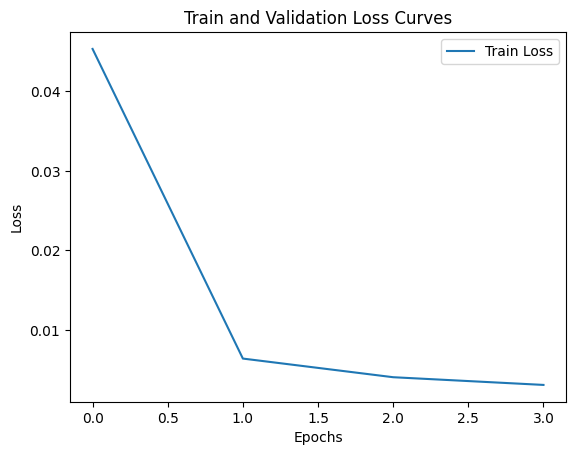

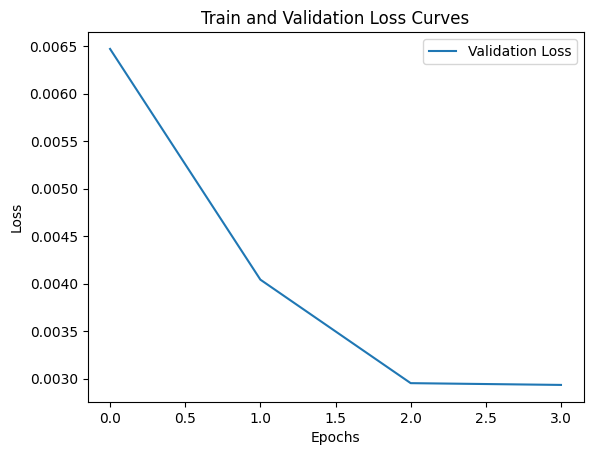

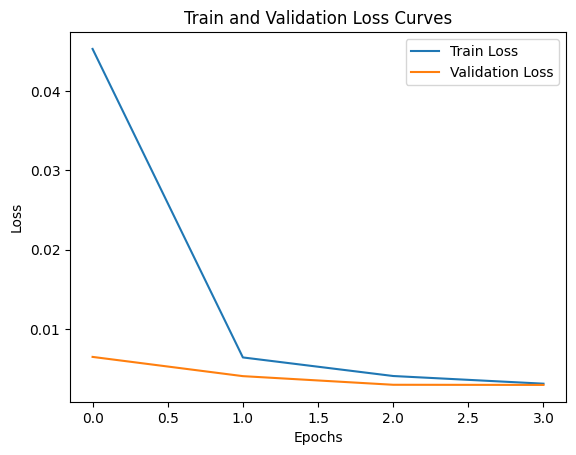

In [33]:
if len(train_loss_list) > 0 and len(valid_loss_list) > 0:
    plt.plot(range(EPOCHS), train_loss_list, label="Train Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss Curves")
    plt.legend()
    plt.show()


    plt.plot(range(EPOCHS), valid_loss_list, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss Curves")
    plt.legend()
    plt.show()

    #plot loss curves

    plt.plot(range(EPOCHS), train_loss_list, label="Train Loss")
    plt.plot(range(EPOCHS), valid_loss_list, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss Curves")
    plt.legend()
    plt.show()

In [34]:
CONF_THRESHOLD = 0.5

def checkmodel(image_path, model, model_path):
    state_dict = torch.load(model_path, weights_only=True)
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()

    image = Image.open(image_path).convert("RGB")
    orig_w, orig_h = image.size
    image_batch = transform(image.resize((IMAGE_WIDTH, IMAGE_HEIGHT))).unsqueeze(0).to(device)

    with torch.no_grad():
        coords, conf_logits = model(image_batch)

    conf = torch.sigmoid(conf_logits).item()

    if conf < CONF_THRESHOLD:
        print(f"No tag detected — conf={conf:.3f}")
        return None

    coords = coords.squeeze(0).cpu().numpy()
    for i in range(0, 8, 2):
        coords[i] *= orig_w
        coords[i+1] *= orig_h

    corners = [(coords[i], coords[i+1]) for i in range(0, 8, 2)]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(Image.open(image_path))
    xs, ys = zip(*(corners + [corners[0]]))
    ax.plot(xs, ys, 'g-', linewidth=2)
    for i, (cx, cy) in enumerate(corners):
        ax.plot(cx, cy, 'ro', markersize=8)
        ax.text(cx + 5, cy - 5, f'C{i+1}', color='yellow', fontsize=10, fontweight='bold')
    ax.set_title(f"Confidence: {conf:.3f}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return corners

In [ ]:
image_name = "/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images/A0044MGO_Flash0_A0044MGOfullhd_1632980533838_2.0.7.png"
checkmodel(image_name, model=model,model_path="/content/trained_models/last.pt")
